In [2]:
import torch
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import sys 
sys.path.append("../")

from checkpoint import CheckPoint

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
st_1 = CheckPoint.from_pt(path="../models/num_permuted_alphabets/MLC_batchalph_dallstudy1_copy_perm20_nep20.pt")
st_2 = CheckPoint.from_pt(path="../models/copy_nstudy/MLC_batchstudy_alph_dallstudy2_copy_perm20_nep20.pt")
st_3 = CheckPoint.from_pt(path="../models/copy_nstudy/MLC_batchstudy_alph_dallstudy3_copy_perm20_nep20.pt")
st_4 = CheckPoint.from_pt(path="../models/copy_nstudy/MLC_batchstudy_alph_dallstudy4_copy_perm20_nep20.pt")
st_5 = CheckPoint.from_pt(path="../models/copy_nstudy/MLC_batchstudy_alph_dallstudy5_copy_perm20_nep20.pt")

all_training_runs = [st_1, st_2, st_3, st_4, st_5]

In [4]:
val_accs = pd.DataFrame()
for n, cp in enumerate(all_training_runs, start=1):
    df = pd.DataFrame(cp.val_acc_hist)
    df["n_study"] = n
    val_accs = pd.concat([val_accs, df])

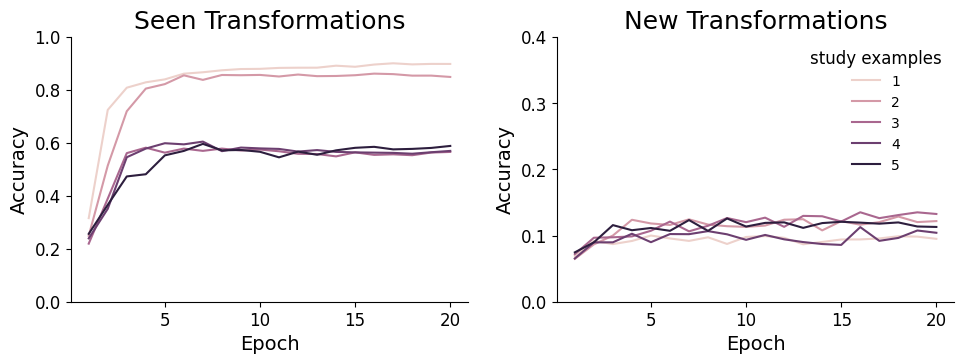

In [ ]:
# Figure 1 Appendix
plt.style.use("./figures_stylesheet.mplstyle")
fig, ax = plt.subplots(1,2, figsize=(10,4))
_ = sns.lineplot(val_accs, x="epoch", y="in", hue="n_study", ax=ax[0])
_ = ax[0].set_xlabel("Epoch")
_ = ax[0].set_ylabel("Accuracy")
_ = ax[0].set_xticks([5,10,15,20])
_ = ax[0].set_ylim((0,1))
_ = ax[0].set_title("Seen Transformations")

_ = ax[0].legend().remove()
_ = sns.lineplot(val_accs, x="epoch", y="out-of", hue="n_study", ax=ax[1])
_ = ax[1].legend(title="study examples", loc='upper right')
_ = ax[1].set_xlabel("Epoch")
_ = ax[1].set_ylabel("Accuracy")
_ = ax[1].set_ylim((0,0.3))
_ = ax[1].set_xticks([5,10,15,20])
_ = ax[1].set_yticks([0, 0.1, 0.2, 0.3, 0.4])
_ = ax[1].set_title("New Transformations")

_ = fig.tight_layout(pad=2)

In [ ]:
# Table 1 Appendix
print("Final Overall Val. Accuracies")
overall_accs = val_accs[val_accs["epoch"]==20][["n_study", "overall"]]
overall_accs

Final Overall Val. Accuracies


,n_study,overall
19,1,0.624714
19,2,0.536501
19,3,0.361684
19,4,0.351655
19,5,0.371229
